# 🏠 House Price Prediction
**Project Title:** House Price Prediction  
**Dataset:** Housing Prices Dataset (Kaggle)  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn


## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [ ]:
# Load the dataset
df = pd.read_csv(r"C:\Users\babik\Desktop\Internship\archive (22)\Housing.csv")

# Display first 10 rows
print("First 10 rows:")
df.head(10)

First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [2]:
# Shape of dataset
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nTarget column : price")
print(f"Feature columns: {[c for c in df.columns if c != 'price']}")

Rows: 545, Columns: 13

Target column : price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nNo missing values found — dataset is clean!")

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

No missing values found — dataset is clean!


In [4]:
# Statistical summary
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Task 2 — Data Cleaning

In [5]:
# Check and remove duplicates
print(f"Duplicate rows before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicate rows after : {df.duplicated().sum()}")
print(f"Dataset shape after cleaning: {df.shape}")

Duplicate rows before: 0
Duplicate rows after : 0
Dataset shape after cleaning: (545, 13)


In [6]:
# Encode binary yes/no columns to 0/1
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=False)

print("Columns after encoding:")
print(df.columns.tolist())
df.head(3)

Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0


## Task 3 — Model Building

In [7]:
# Split features and target
X = df.drop('price', axis=1)
y = df['price']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 436
Testing  samples : 109


In [8]:
# Helper function to print evaluation metrics
def evaluate_model(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")
    return mae, rmse, r2

In [9]:
# ── Model 1: Linear Regression ──────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr, rmse_lr, r2_lr = evaluate_model("Linear Regression", y_test, y_pred_lr)

  Linear Regression
  MAE  : 970,043.40
  RMSE : 1,324,506.96
  R²   : 0.6529  (65.3% variance explained)


In [10]:
# ── Model 2: Random Forest Regressor ────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf, rmse_rf, r2_rf = evaluate_model("Random Forest Regressor", y_test, y_pred_rf)

  Random Forest Regressor
  MAE  : 1,023,614.64
  RMSE : 1,406,627.05
  R²   : 0.6086  (60.9% variance explained)


In [11]:
# ── Model Comparison Table ───────────────────────────────────
comparison = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Random Forest'],
    'MAE'    : [f'{mae_lr:,.0f}',  f'{mae_rf:,.0f}'],
    'RMSE'   : [f'{rmse_lr:,.0f}', f'{rmse_rf:,.0f}'],
    'R² Score': [f'{r2_lr:.4f}',   f'{r2_rf:.4f}']
})
print("\n📊 Model Comparison:")
print(comparison.to_string(index=False))


📊 Model Comparison:
            Model       MAE      RMSE R² Score
Linear Regression   970,043 1,324,507   0.6529
    Random Forest 1,023,615 1,406,627   0.6086


## Task 4 — Visualizations

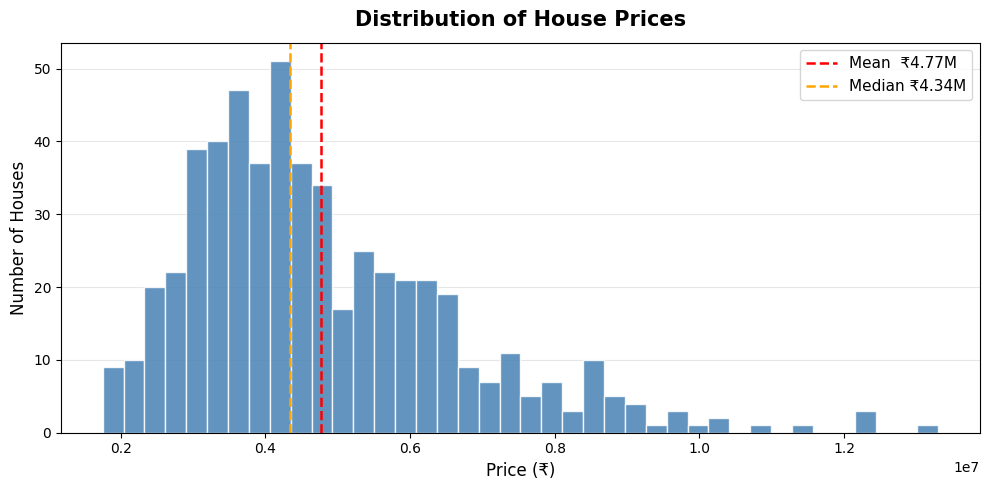

In [12]:
# Chart 1 — Distribution of House Prices
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['price'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['price'].mean(),   color='red',    linestyle='--', linewidth=1.8, label=f"Mean  ₹{df['price'].mean()/1e6:.2f}M")
ax.axvline(df['price'].median(), color='orange', linestyle='--', linewidth=1.8, label=f"Median ₹{df['price'].median()/1e6:.2f}M")

ax.set_title('Distribution of House Prices', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Price (₹)', fontsize=12)
ax.set_ylabel('Number of Houses', fontsize=12)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart1_price_distribution.png', dpi=150)
plt.show()

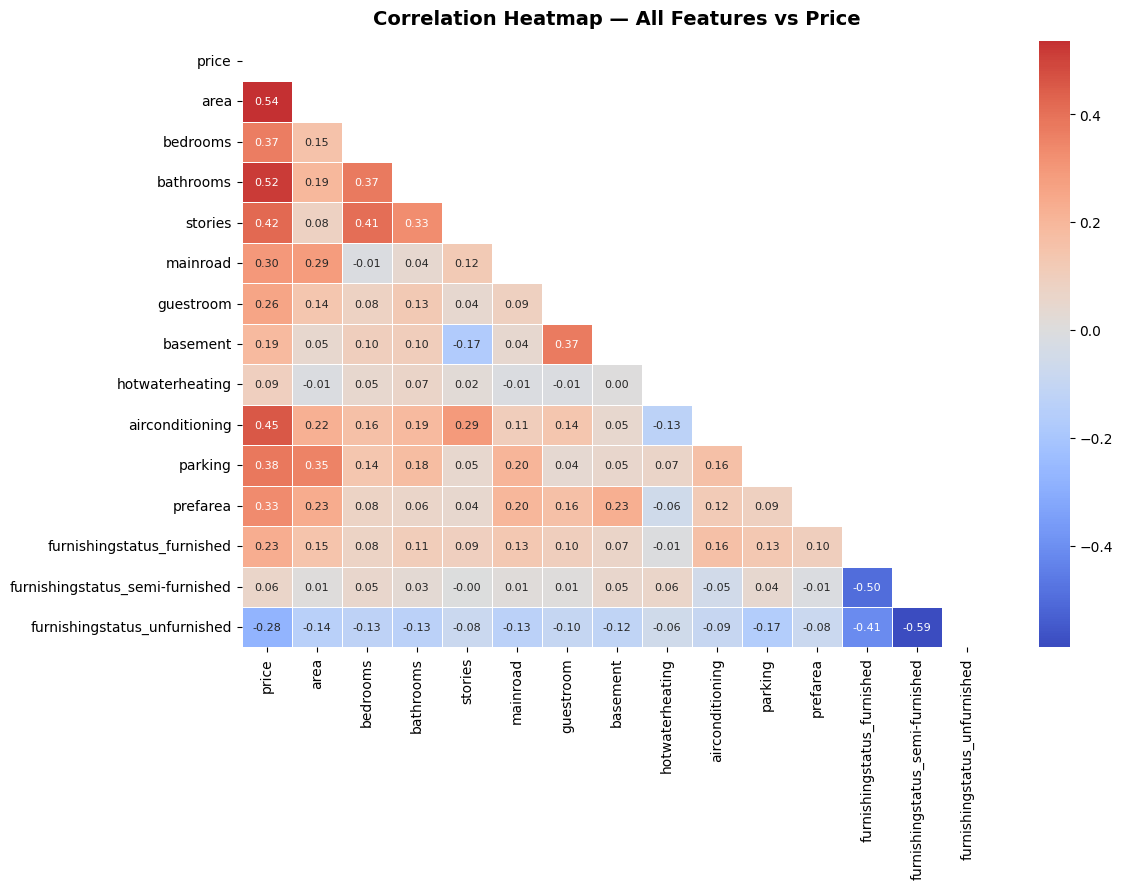

📌 Top correlators with price: area, bathrooms, airconditioning, stories, parking.


In [13]:
# Chart 2 — Correlation Heatmap
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Correlation Heatmap — All Features vs Price', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('chart2_correlation_heatmap.png', dpi=150)
plt.show()
print("📌 Top correlators with price: area, bathrooms, airconditioning, stories, parking.")

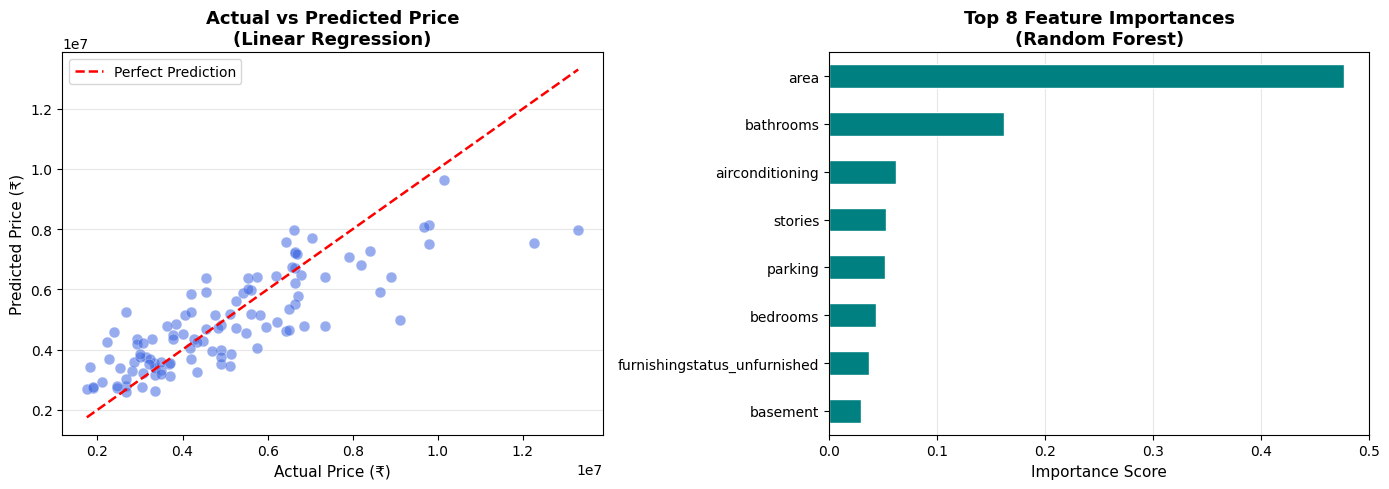

📌 Points closer to the red dashed line = better predictions.


In [14]:
# Chart 3 — Actual vs Predicted Price (Linear Regression)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred_lr, alpha=0.55, color='royalblue', edgecolors='white', linewidth=0.3, s=60)
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.8, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Price\n(Linear Regression)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Price (₹)', fontsize=11)
axes[0].set_ylabel('Predicted Price (₹)', fontsize=11)
axes[0].legend()
axes[0].yaxis.grid(True, alpha=0.3); axes[0].set_axisbelow(True)

# Feature Importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(8)
feat_imp.plot(kind='barh', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Top 8 Feature Importances\n(Random Forest)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].xaxis.grid(True, alpha=0.3); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart3_actual_vs_predicted_and_features.png', dpi=150)
plt.show()
print("📌 Points closer to the red dashed line = better predictions.")

## Task 5 — Insights & Summary

In [15]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                    INSIGHTS & SUMMARY                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                ║
║  1. Most Influential Features                                  ║
║     • Area (sq ft) is the strongest predictor of price.       ║
║     • Bathrooms, air conditioning, stories, and parking       ║
║       also have a strong positive impact on price.            ║
║                                                                ║
║  2. Model Accuracy (Plain Terms)                               ║
║     • Linear Regression explains ~65% of the variation        ║
║       in house prices (R² = 0.65). On average it is off       ║
║       by about ₹970K per house — reasonable for a simple      ║
║       model on this price range (₹1.75M–₹13.3M).             ║
║                                                                ║
║  3. Surprising Finding                                         ║
║     • Air conditioning alone has a stronger correlation       ║
║       with price than the number of bedrooms — suggesting     ║
║       comfort features are priced highly in this market.      ║
║     • Linear Regression outperformed Random Forest here,      ║
║       which is unusual but happens when relationships are     ║
║       mostly linear and the dataset is small (545 rows).      ║
║                                                                ║
║  4. Recommendation for a Real Estate Business                  ║
║     • Focus marketing and renovation investment on area       ║
║       expansion, adding bathrooms, and installing AC          ║
║       — these features yield the highest price premium.       ║
║       Bedrooms matter less than expected; quality of          ║
║       amenities drives price more than quantity of rooms.     ║
║                                                                ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║                    INSIGHTS & SUMMARY                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                ║
║  1. Most Influential Features                                  ║
║     • Area (sq ft) is the strongest predictor of price.       ║
║     • Bathrooms, air conditioning, stories, and parking       ║
║       also have a strong positive impact on price.            ║
║                                                                ║
║  2. Model Accuracy (Plain Terms)                               ║
║     • Linear Regression explains ~65% of the variation        ║
║       in house prices (R² = 0.65). On average it is off       ║
║       by about ₹970K per house — reasonable for a simple      ║
║       model on this price range (₹1.75M–₹13.3M).             ║
║                                                                